# 03 - Model Training and Evaluation

This notebook focuses on training and evaluating machine learning classification models for diabetes prediction.

The cleaned dataset from the preprocessing notebook is used to train and compare multiple classification algorithms.

## 1. Notebook Objective

The goal of this notebook is to build and evaluate machine learning classification models using the cleaned diabetes prediction dataset.

In this notebook, the following steps are performed:

- Loading the cleaned dataset
- Encoding the remaining categorical feature
- Separating features and target variable
- Splitting the data into training and test sets
- Scaling numerical features
- Training classification models
- Performing hyperparameter tuning for SVM
- Evaluating models using classification metrics
- Comparing model performances
- Saving the best-performing model and preprocessing objects

The models used in this project are:

- Logistic Regression
- Support Vector Machine
- Gaussian Naive Bayes

## 2. Import Libraries

In this section, the required Python libraries are imported.

The notebook uses `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for visualization, and Scikit-learn for preprocessing, model training, hyperparameter tuning, and evaluation.

In [36]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import joblib
from sklearn.model_selection import GridSearchCV
%matplotlib inline

## 3. Data Loading

The cleaned dataset created in the previous preprocessing notebook is loaded from the `data/processed` directory.

This dataset has already gone through basic cleaning steps such as duplicate removal, rare category handling, and binary encoding of the `gender` feature.

In [2]:
df = pd.read_csv("../data/processed/diabetes_cleaned.csv")

## 4. Dataset Overview

Before model training, the dataset structure is checked again to confirm the number of rows, columns, data types, and whether any non-numerical columns still remain.

At this stage, the only remaining categorical feature should be `smoking_history`, which will be encoded before training the models.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96128 entries, 0 to 96127
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96128 non-null  int64  
 1   age                  96128 non-null  float64
 2   hypertension         96128 non-null  int64  
 3   heart_disease        96128 non-null  int64  
 4   smoking_history      96128 non-null  object 
 5   bmi                  96128 non-null  float64
 6   HbA1c_level          96128 non-null  float64
 7   blood_glucose_level  96128 non-null  int64  
 8   diabetes             96128 non-null  int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 6.6+ MB


## 5. One-Hot Encoding for Smoking History

The `smoking_history` feature contains multiple categories and does not have a natural numerical order.

Therefore, one-hot encoding is applied using Scikit-learn's `OneHotEncoder`. This method creates separate binary columns for each smoking history category.

The parameter `drop="first"` is used to remove the first category and reduce redundant information. The parameter `handle_unknown="ignore"` helps avoid errors if an unseen category appears in future data.

In [4]:
encoder = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

In [5]:
encoded_smoking = encoder.fit_transform(df[["smoking_history"]])
encoded_columns = encoder.get_feature_names_out(["smoking_history"])

In [6]:
encoded_smoking

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.]], shape=(96128, 5))

In [7]:
encoded_df = pd.DataFrame(
    encoded_smoking,
    columns=encoded_columns
)

In [8]:
encoded_df

,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
96123,0.0,0.0,0.0,0.0,0.0
96124,0.0,0.0,0.0,0.0,0.0
96125,0.0,0.0,1.0,0.0,0.0
96126,0.0,0.0,0.0,1.0,0.0


After one-hot encoding, the new encoded columns are converted into a DataFrame and combined with the original dataset.

The original `smoking_history` column is then removed because its information is now represented by the newly created binary columns.

In [9]:
df = pd.concat([df,encoded_df], axis=1)

In [10]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0,80.0,0,1,never,25.19,6.6,140,0,0.0,0.0,0.0,1.0,0.0
1,0,54.0,0,0,No Info,27.32,6.6,80,0,0.0,0.0,0.0,0.0,0.0
2,1,28.0,0,0,never,27.32,5.7,158,0,0.0,0.0,0.0,1.0,0.0
3,0,36.0,0,0,current,23.45,5.0,155,0,1.0,0.0,0.0,0.0,0.0
4,1,76.0,1,1,current,20.14,4.8,155,0,1.0,0.0,0.0,0.0,0.0


In [11]:
df = df.drop("smoking_history", axis=1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96128 entries, 0 to 96127
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       96128 non-null  int64  
 1   age                          96128 non-null  float64
 2   hypertension                 96128 non-null  int64  
 3   heart_disease                96128 non-null  int64  
 4   bmi                          96128 non-null  float64
 5   HbA1c_level                  96128 non-null  float64
 6   blood_glucose_level          96128 non-null  int64  
 7   diabetes                     96128 non-null  int64  
 8   smoking_history_current      96128 non-null  float64
 9   smoking_history_ever         96128 non-null  float64
 10  smoking_history_former       96128 non-null  float64
 11  smoking_history_never        96128 non-null  float64
 12  smoking_history_not current  96128 non-null  float64
dtypes: float64(8), i

## 6. Feature and Target Separation

The target variable is `diabetes`, which indicates whether a person has diabetes or not.

All remaining columns are used as input features for model training.

In [13]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

## 7. Train-Test Split

The dataset is split into training and test sets.

The training set is used to train the models, while the test set is used to evaluate how well the models perform on unseen data.

Stratified splitting is used to preserve the class distribution of the target variable in both training and test sets.

In [45]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15, stratify=y)

## 8. Feature Scaling

Feature scaling is applied using `StandardScaler`.

Scaling is especially important for algorithms such as Logistic Regression and Support Vector Machine because these models are sensitive to differences in feature magnitudes.

The scaler is fitted only on the training data, and the same transformation is applied to the test data. This prevents data leakage from the test set into the training process.

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 9. Logistic Regression Model

Logistic Regression is used as the first baseline classification model.

It is a simple, interpretable, and commonly used algorithm for binary classification problems. In this project, it provides a useful baseline for comparing more complex models.

In [16]:
logistic = LogisticRegression()

In [17]:
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     21887
           1       0.88      0.63      0.74      2145

    accuracy                           0.96     24032
   macro avg       0.92      0.81      0.86     24032
weighted avg       0.96      0.96      0.96     24032



The classification report shows the model's precision, recall, F1-score, and support values for each class.

For this healthcare-related problem, recall is especially important because failing to identify diabetic patients may be more critical than producing some false positives.

## 10. Support Vector Machine Model

Support Vector Machine is used as another classification model.

SVM tries to find a decision boundary that separates classes as effectively as possible. Since SVM is sensitive to feature scales, the scaled dataset is used for training.

In [18]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

In [19]:
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': ["scale", "auto"],
              'kernel': ['rbf','sigmoid','poly']}

## 11. Hyperparameter Tuning with GridSearchCV

GridSearchCV is used to find the best hyperparameter combination for the SVM model.

The search process tests different values of `C`, `gamma`, and `kernel` using cross-validation. The best model is selected based on the F1-score.

F1-score is used because it balances precision and recall, which is useful for classification problems with potential class imbalance.

In [20]:
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    verbose=3,
    n_jobs=-1
)

In [21]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.676 total time=  33.7s
[CV 1/5] END ...C=0.1, gamma=scale, kernel=poly;, score=0.719 total time=  22.7s
[CV 2/5] END .C=0.1, gamma=auto, kernel=sigmoid;, score=0.539 total time=  52.3s
[CV 3/5] END ..C=1, gamma=scale, kernel=sigmoid;, score=0.502 total time=  37.1s
[CV 1/5] END .......C=1, gamma=auto, kernel=rbf;, score=0.732 total time=  30.6s
[CV 1/5] END ......C=1, gamma=auto, kernel=poly;, score=0.746 total time=  27.8s
[CV 1/5] END .C=10, gamma=scale, kernel=sigmoid;, score=0.514 total time=  40.7s
[CV 2/5] END ......C=10, gamma=auto, kernel=rbf;, score=0.740 total time=  41.5s
[CV 2/5] END ..C=10, gamma=auto, kernel=sigmoid;, score=0.528 total time=  41.3s
[CV 4/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.773 total time= 1.2min
[CV 4/5] END .....C=100, gamma=auto, kernel=rbf;, score=0.772 total time= 1.2min
[CV 4/5] END .C=100, gamma=auto, kernel=sigmoid

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'sigmoid', ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1000


In [22]:
grid.best_params_

{'C': 1000, 'gamma': 'scale', 'kernel': 'poly'}

The best parameter combination found by GridSearchCV is used as the final SVM model for evaluation on the test set.

In [23]:
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     21887
           1       0.99      0.64      0.77      2145

    accuracy                           0.97     24032
   macro avg       0.98      0.82      0.88     24032
weighted avg       0.97      0.97      0.96     24032



## 12. SVM Model Evaluation

The best SVM model selected by GridSearchCV is evaluated on the test set.

The classification report and confusion matrix are used to analyze the model's performance in terms of correct predictions, false positives, and false negatives.

In [25]:
print(confusion_matrix(y_test,y_pred))

[[21872    15]
 [  781  1364]]


In [29]:
best_model = grid.best_estimator_
joblib.dump(
    best_model,
    "../Models/best_svm_model.pkl"
)

['../Models/best_svm_model.pkl']

## 13. Gaussian Naive Bayes Model

Gaussian Naive Bayes is used as the third classification model.

This algorithm is based on Bayes' theorem and assumes that features are conditionally independent given the class label.

Although this assumption may not always fully hold in real-world datasets, Naive Bayes is fast, simple, and useful as a baseline classification model.

In [30]:
gnb = GaussianNB()

In [32]:
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

In [34]:
print("confusion matrix: \n", confusion_matrix(y_test, y_pred))
print("classification report: \n", classification_report(y_test, y_pred))

confusion matrix: 
 [[20275  1612]
 [  724  1421]]
classification report: 
               precision    recall  f1-score   support

           0       0.97      0.93      0.95     21887
           1       0.47      0.66      0.55      2145

    accuracy                           0.90     24032
   macro avg       0.72      0.79      0.75     24032
weighted avg       0.92      0.90      0.91     24032



The Gaussian Naive Bayes model is evaluated using the same metrics as the other models to ensure a fair comparison.

In [35]:
joblib.dump(encoder, "../models/onehot_encoder.pkl")
joblib.dump(scaler, "../models/standard_scaler.pkl")
joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")
joblib.dump(best_model, "../models/best_svm_model.pkl")

['../models/best_svm_model.pkl']

In [48]:
y_pred_logistic = logistic.predict(X_test)
y_pred_svm = grid.predict(X_test)
y_pred_nb = gnb.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


## 14. Model Comparison

To compare the models fairly, predictions are generated separately for each trained model.

Accuracy, precision, recall, and F1-score are calculated for each model and stored in a comparison table.

In [49]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_logistic),
        "Precision": precision_score(y_test, y_pred_logistic),
        "Recall": recall_score(y_test, y_pred_logistic),
        "F1-Score": f1_score(y_test, y_pred_logistic)
    },
    {
        "Model": "SVM",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm),
        "Recall": recall_score(y_test, y_pred_svm),
        "F1-Score": f1_score(y_test, y_pred_svm)
    },
    {
        "Model": "Naive Bayes",
        "Accuracy": accuracy_score(y_test, y_pred_nb),
        "Precision": precision_score(y_test, y_pred_nb),
        "Recall": recall_score(y_test, y_pred_nb),
        "F1-Score": f1_score(y_test, y_pred_nb)
    }
]

results_df = pd.DataFrame(results)
results_df
results_df.to_csv("../outputs/reports/model_comparison.csv", index=False)

## 15. Confusion Matrix Visualization

A confusion matrix is created for the best-performing model to better understand its classification behavior.

The confusion matrix shows:

- True negatives
- False positives
- False negatives
- True positives

This is useful for understanding how many diabetic and non-diabetic cases were correctly or incorrectly classified.

[[20275  1612]
 [  724  1421]]


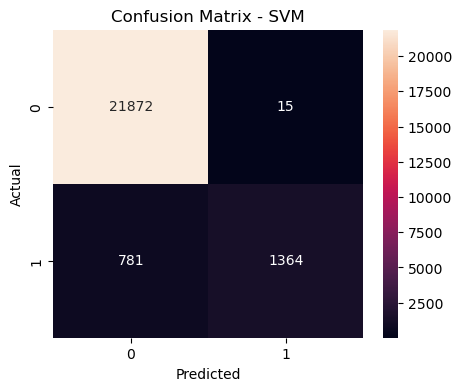

In [42]:
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
plt.savefig("../outputs/figures/confusion_matrix_svm.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## 17. Final Conclusion

In this notebook, three machine learning classification models were trained and evaluated for diabetes prediction:

- Logistic Regression
- Support Vector Machine
- Gaussian Naive Bayes

The dataset was prepared by applying one-hot encoding to the `smoking_history` feature and scaling the numerical features using `StandardScaler`.

Logistic Regression was used as a baseline model, SVM was optimized using GridSearchCV, and Gaussian Naive Bayes was used as a fast probabilistic baseline.

The models were evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

Since this project focuses on a healthcare-related classification problem, recall and F1-score were considered especially important metrics. Detecting actual diabetic patients is more critical than relying only on overall accuracy.

The best-performing model and preprocessing objects were saved for future use.